In [1]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

with h5py.File("4x4_alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

import scipy.spatial

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

import sys
import os

module_path = os.path.abspath(os.path.join("../../src/"))
if module_path not in sys.path:
    sys.path.append(module_path)

from HubbardTweezer.Hubbard.lattice import sqr_lattice

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array([4, 4]))
xlinks = abs(links[:, 0] - links[:, 1]) == 1
ylinks = np.logical_not(xlinks)
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

Vi = dat["V_i"]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

3003
1187


# Analysis

## Single trap depth

Text(0, 0.5, 'V')

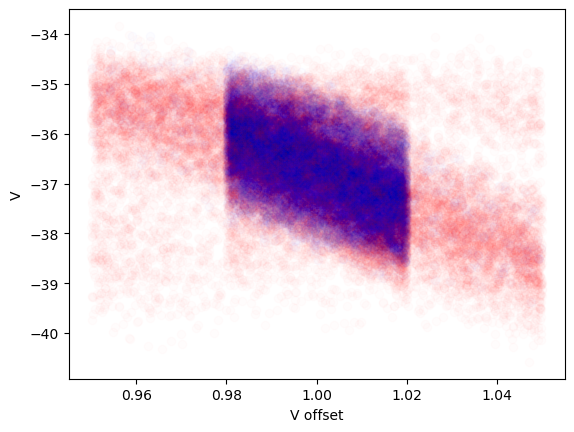

In [5]:
plt.scatter(
    dat["V_offset"][~mask].flatten(),
    Vi[~mask].flatten(),
    color="r",
    alpha=1e-2,
)
plt.scatter(
    dat["V_offset"][mask].flatten(),
    Vi[mask].flatten(),
    color="b",
    alpha=1e-2,
)
plt.xlabel("V offset")
plt.ylabel("V")

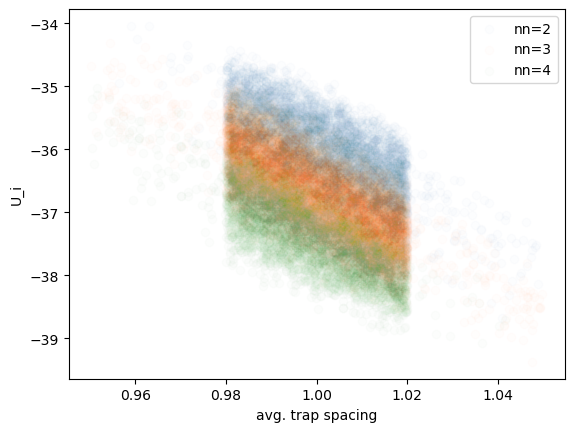

In [45]:
import matplotlib.pyplot as plt

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        dat["V_offset"][mask][:, nno == i],
        Vi[mask][:, nno == i].flatten(),
        alpha=1e-2,
        label=f"nn={i}",
    )
plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

## Positions

### No. of neighbours

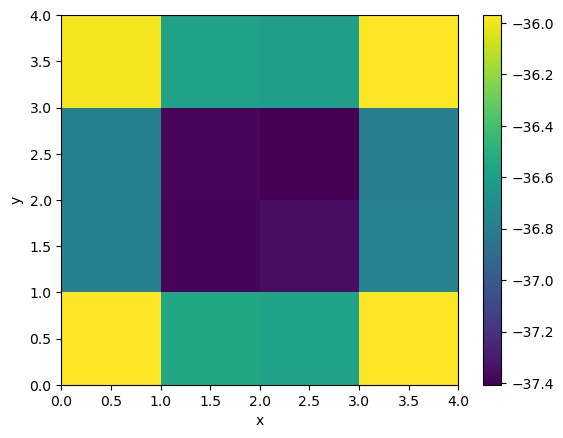

In [8]:
avgV = np.mean(Vi[mask], axis=0)
plt.pcolormesh(avgV.reshape(4, 4))
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar()

In [9]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


nno = nneighbor(width, height)

In [10]:
avgV = np.mean(Vi[mask], axis=0)

Text(0, 0.5, 'U_i')

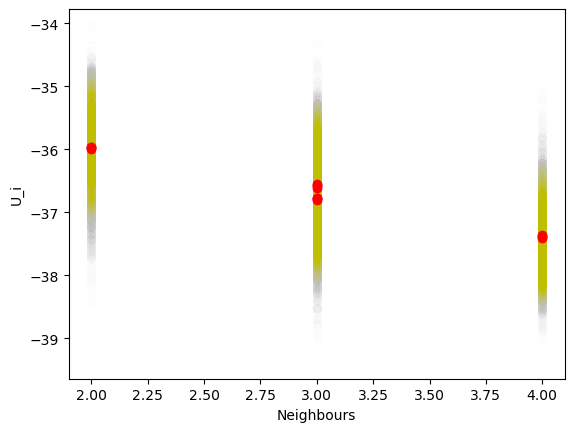

In [11]:
sidx = list(range(16))
plt.scatter(np.tile(nno, nmask), Vi[mask][:, sidx].flatten(), color="y", alpha=2e-3)
plt.scatter(nno, avgV[sidx].flatten(), color="r", alpha=1)
plt.xlabel("Neighbours")
plt.ylabel("U_i")

There is a dependence of V_i on trap neighbor number.

Study the correlation of V_offset dependence on the number of neighbours.

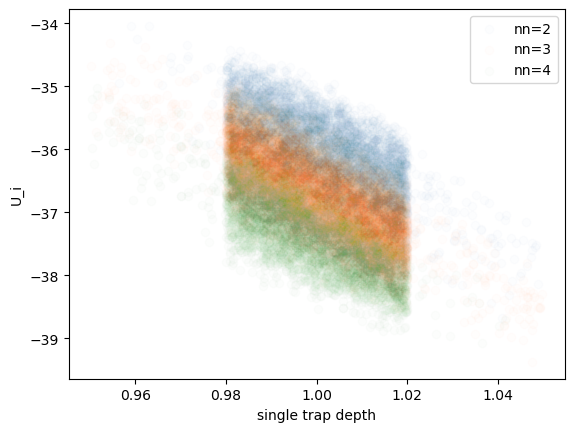

In [12]:
for i in [2, 3, 4]:
    plt.scatter(
        dat["V_offset"][mask][:, nno == i],
        Vi[mask][:, nno == i].flatten(),
        alpha=1e-2,
        label=f"nn={i}",
    )
plt.xlabel("single trap depth")
plt.ylabel("U_i")
plt.legend()

The V_offset slope has no clear dependence on the neighboring number.

### Avg. trap spacing

In [13]:
from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr


avgr = avg_trap_spacing(np.arange(width * height)).T

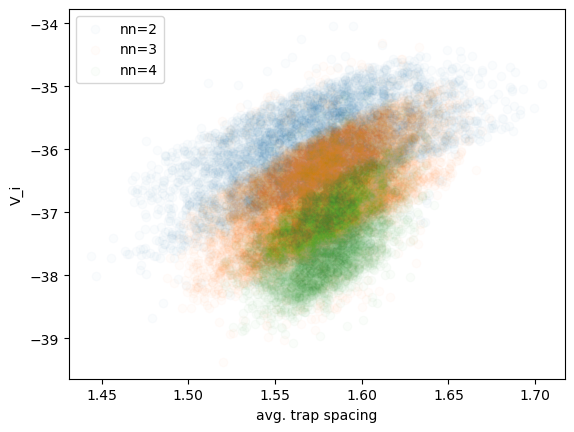

In [14]:
for i in [2, 3, 4]:
    plt.scatter(
        avgr[:, nno == i], Vi[mask][:, nno == i].flatten(), alpha=2e-2, label=f"nn={i}"
    )
plt.xlabel("avg. trap spacing")
plt.ylabel("V_i")
plt.legend()

The dependence seems to be more complex. Less clear dependence on trap spacing.

In [15]:
from typing import Iterable


def tot_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([tot_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    totr = np.sum(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return totr


totr = tot_trap_spacing(np.arange(16)).T

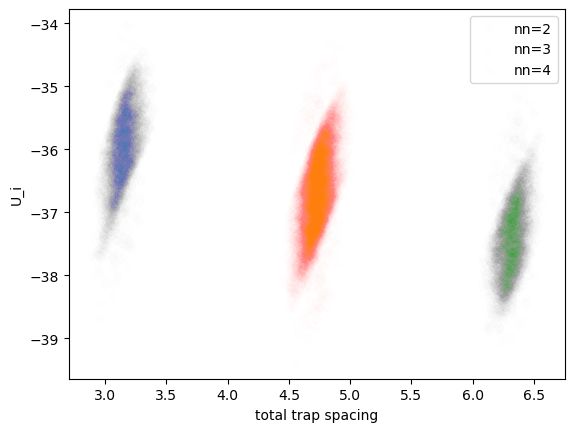

In [16]:
for i in [2, 3, 4]:
    plt.scatter(
        totr[:, nno == i], Vi[mask][:, nno == i].flatten(), alpha=5e-3, label=f"nn={i}"
    )
plt.xlabel("total trap spacing")
plt.ylabel("U_i")
plt.legend()

In [17]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


from typing import Iterable


def avg_trap_spacing(links, idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(links, i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr


nno = nneighbor(width, height)
avgrx = avg_trap_spacing(links[xlinks], np.arange(width * height)).T
avgry = avg_trap_spacing(links[ylinks], np.arange(width * height)).T

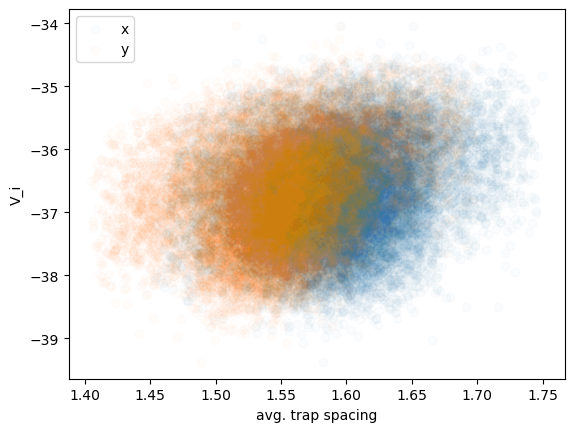

In [18]:
plt.scatter(avgrx, Vi[mask].flatten(), alpha=2e-2, label=f"x")
plt.scatter(avgry, Vi[mask].flatten(), alpha=2e-2, label=f"y")
plt.xlabel("avg. trap spacing")
plt.ylabel("V_i")
plt.legend()

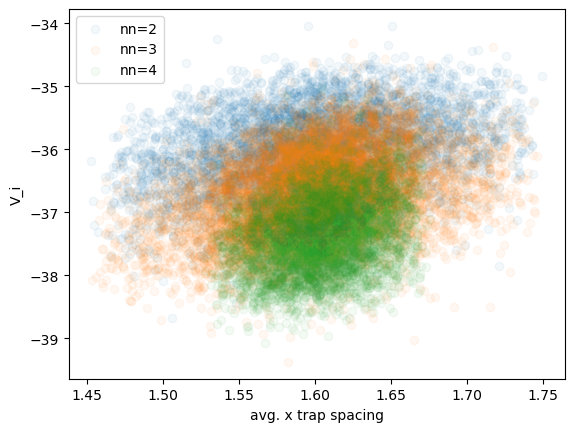

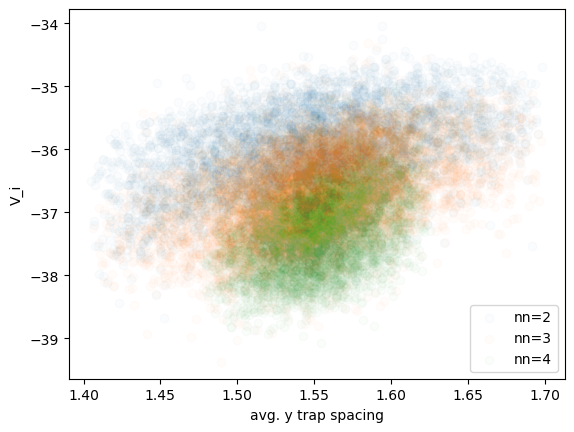

In [19]:
for i in [2, 3, 4]:
    plt.scatter(
        avgrx[:, nno == i], Vi[mask][:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}"
    )
plt.xlabel("avg. x trap spacing")
plt.ylabel("V_i")
plt.legend()

plt.figure()
for i in [2, 3, 4]:
    plt.scatter(
        avgry[:, nno == i], Vi[mask][:, nno == i].flatten(), alpha=2e-2, label=f"nn={i}"
    )
plt.xlabel("avg. y trap spacing")
plt.ylabel("V_i")
plt.legend()

The dependence on trap spacing is not clear. But x, y follows the same law is sure.

### x y trap spacing

In [20]:
from typing import Iterable

# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbors(index, width, height):
    if isinstance(index, Iterable):
        return np.array([nneighbors(i, width, height) for i in index])
    x = index % width
    y = index // height
    count = np.zeros(2, dtype=int)
    count[0] += 1 if x > 0 else 0  # left neighbor
    count[0] += 1 if x < width - 1 else 0  # right neighbor
    count[1] += 1 if y > 0 else 0  # top neighbor
    count[1] += 1 if y < height - 1 else 0  # bottom neighbor
    return count


nnxy = nneighbors(np.arange(16), width, height).T


def spacings(index, width, height):
    if isinstance(index, Iterable):
        return np.array([spacings(i, width, height) for i in index])
    x = index % width
    y = index // height
    xm1 = x - 1 if x > 0 else 0
    xp1 = x + 1 if x < width - 1 else width - 1
    ym1 = y - 1 if y > 0 else 0
    yp1 = y + 1 if y < height - 1 else height - 1
    return [y * width + xm1, y * width + xp1, ym1 * width + x, yp1 * width + x]


nidx = spacings(np.arange(16), width, height).T
xspacing = dat["rij"][mask][:, nidx[0], nidx[1]] / nnxy[0][None]
yspacing = dat["rij"][mask][:, nidx[2], nidx[3]] / nnxy[1][None]
spacing = [xspacing, yspacing]

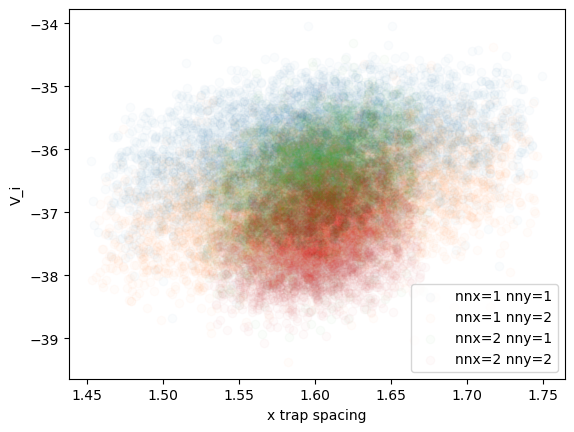

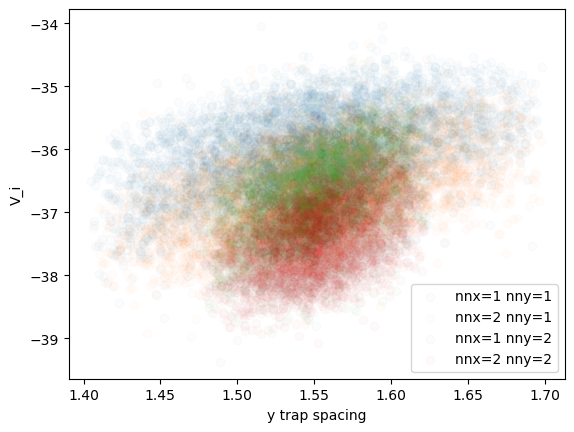

In [21]:
d = ["x", "y"]
k = 0
plt.figure()

for i in [1, 2]:
    for j in [1, 2]:
        plt.scatter(
            spacing[k][:, (nnxy[k] == i) * (nnxy[1 - k] == j)],
            Vi[mask][:, (nnxy[k] == i) * (nnxy[1 - k] == j)].flatten(),
            alpha=2e-2,
            label=f"nnx={i} nny={j}",
        )


plt.xlabel(f"{d[k]} trap spacing")
plt.ylabel("V_i")
plt.legend()

k = 1
plt.figure()
for i in [1, 2]:
    for j in [1, 2]:
        plt.scatter(
            spacing[k][:, (nnxy[k] == i) * (nnxy[1 - k] == j)],
            Vi[mask][:, (nnxy[k] == i) * (nnxy[1 - k] == j)].flatten(),
            alpha=2e-2,
            label=f"nnx={j} nny={i}",
        )
plt.xlabel(f"{d[k]} trap spacing")
plt.ylabel("V_i")
plt.legend()

It seems that nny's change doesn't change the model slope of x spacing, vice versa.

The model is additive, not multiplicative.

## Total trap depth

Text(0, 0.5, 'V_tot')

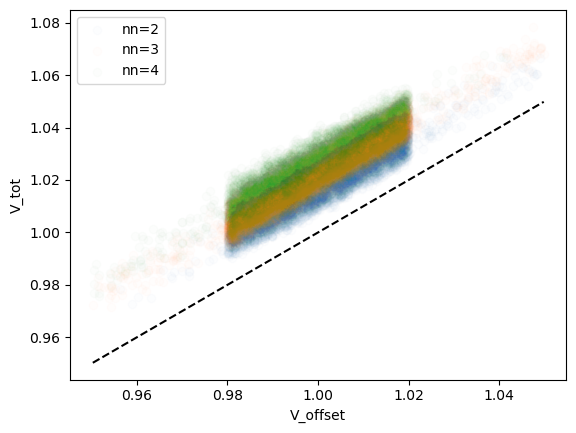

In [ ]:
Voff = dat["V_offset"][mask]
Vtot = dat["V_tot"][mask]
for i in [2, 3, 4]:
    plt.scatter(
        Voff[:, nno == i], Vtot[:, nno == i].flatten(), alpha=1e-2, label=f"nn={i}"
    )
x = np.linspace(Voff.min(), Voff.max(), 100)
plt.plot(x, x, "--k")
plt.legend()
plt.xlabel("V_offset")
plt.ylabel("V_tot")

In [22]:
# zR = 4 * np.ones(2)
wxy = np.ones(2)
# zR0 = np.prod(zR) / np.linalg.norm(zR)
width = 4
height = 4
N = width * height
dim = 3


# def Vfun(x, y, z):
#     d0 = 1 + (z / zR0) ** 2 / 2
#     dxy = (x / wxy[0]) ** 2 / (1 + (z / zR[0]) ** 2)
#     dxy += (y / wxy[1]) ** 2 / (1 + (z / zR[1]) ** 2)
#     V = -1 / d0 * np.exp(-2 * dxy)
#     return V


def Vfun(x, y):
    dxy = x**2 + y**2
    V = -np.exp(-2 * dxy)
    return V


def tot_trap_depth(V0, trap_centers):
    # tc = np.zeros((N, dim))
    tc = np.zeros((N, 2))
    vij = np.ones((N, N))
    for i in range(N):
        # tc[i, :] = np.append(trap_centers[i], 0)
        tc[i, :] = trap_centers[i]
        for j in range(i):
            vij[i, j] = -Vfun(*(tc[i] - tc[j]))
            vij[j, i] = vij[i, j]  # Potential is symmetric in distance
    vtot = vij @ V0
    return vtot


vtot = np.array(
    list(map(tot_trap_depth, dat["V_offset"][mask], dat["trap_centers"][mask]))
)

Text(0, 0.5, 'V')

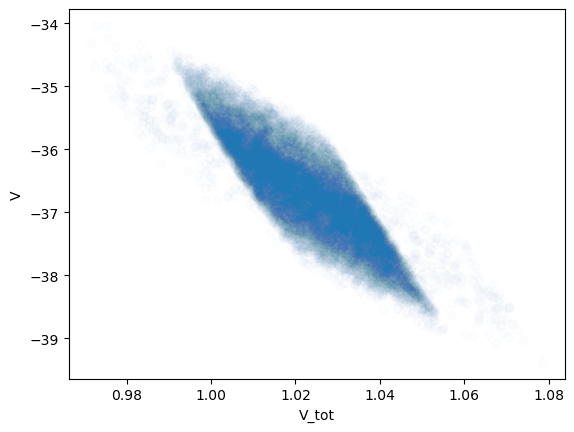

In [23]:
plt.scatter(vtot, Vi[mask], alpha=1e-2)
plt.xlabel("V_tot")
plt.ylabel("V")

Onsite potential is highly, but not only linear to total trap depth.

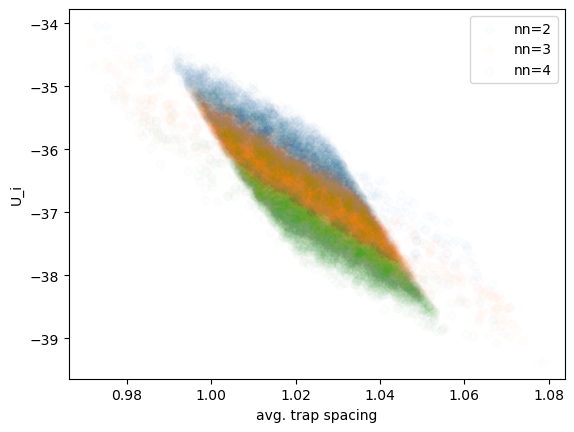

In [24]:
import matplotlib.pyplot as plt

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        vtot[:, nno == i], Vi[mask][:, nno == i].flatten(), alpha=1e-2, label=f"nn={i}"
    )
plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

So the total trap depth accounts part of the effect by neighboring number, but not all.

This is reasonable as we can derive the dependence on trap spacing from a simple harmonic trap approximation.

# Fit the data

## Single factor V_tot

We expect the scaling of $\mu$ to V_offset given by GS energy of the trap according to harmonic approximation: $W \sim \psi_0$

$$ \mu = \int W^\dagger [T+V] W d^3 x \sim E^{\text{GS}}_0 = -V_0 + \frac{3}{2}\hbar \omega = -V_0 + c \sqrt{V_0} $$

Since $c < 1$ first order we assume the dependence is linear. But it can be more accurate if we include the second term with fitting parameter $c$.

The trap spacing and trap neighbor number affect in fact the total trap depth, so that they determine $\mu$. THe Wannier function speradout is not that much important in this case due to the orthonormality of the Wannier functions.

In [27]:
X = dat["V_tot"][mask]
Y = Vi[mask]

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(torch.randn(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter
        self.c = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        return self.a * (-x + self.b * np.sqrt(x)) + self.c


# Convert data to torch tensors
X_torch = torch.tensor(X, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
bx = model.b.item()
c = model.c.item()

print(f"Model: Y = {a} * (-X + {bx} * sqrt(X)) + {c}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 351.4032
Epoch [2/1000], Loss: 0.2769
Epoch [3/1000], Loss: 0.2523
Epoch [4/1000], Loss: 0.2523
Final Loss: 0.2523
Model: Y = 3.756040096282959 * (-X + -25.8936824798584 * sqrt(X)) + 65.50493621826172
R^2 Score: 0.7477242132771816


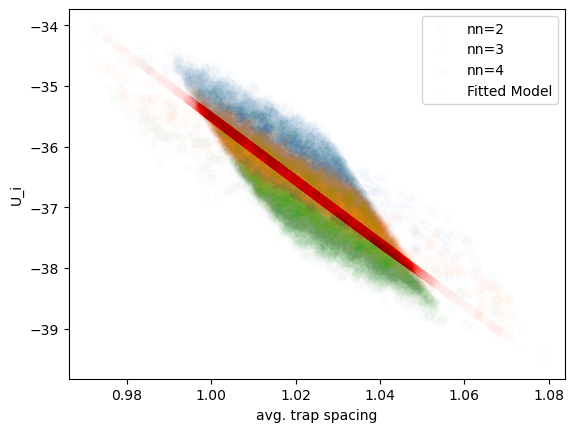

In [29]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(X[:, nno == i], Y[:, nno == i].flatten(), alpha=1e-2, label=f"nn={i}")
# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", alpha=5e-3)

plt.xlabel("tot. trap depth")
plt.ylabel("U_i")
plt.legend()

### (Depracated) Total trap depth replaced by total relative trap depth?

We think of the same model, but with an assumption that the deviation from average is small, then

$$ \tilde{\mu}_i = \mu_i - \bar{\mu}_i \sim -V_{i} +c\sqrt{V_i} + \bar{V}_i - c\bar{\sqrt{V_i}} = -(V_{i} - \bar{V}_i ) +c \frac{V_{i} - \bar{V}_i }{\sqrt{V_i} + \bar{\sqrt{V_i}}} $$

From the assumption, then the second term on $V_{i} - \bar{V}_i$ is still linear, then the whole term can be approximated by a linear model on $V_{i} - \bar{V}_i$.

In [63]:
Voff = dat["V_offset"][mask]
tc = dat["trap_centers"][mask]
X = np.array(list(map(tot_trap_depth, Voff, tc)))
X = X - np.mean(X, axis=1)[:, None]
Y = Vi[mask]

In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(torch.randn(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        return self.a * x + self.b


# Convert data to torch tensors
X_torch = torch.tensor(X, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
bx = model.b.item()

print(f"Model: Y = {a} * X + {bx}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.2603
Epoch [2/1000], Loss: 0.2597
Epoch [3/1000], Loss: 0.2597
Final Loss: 0.2597
Model: Y = -52.072078704833984 * X + -1.644111762288958e-05
R^2 Score: 0.7402948960961351


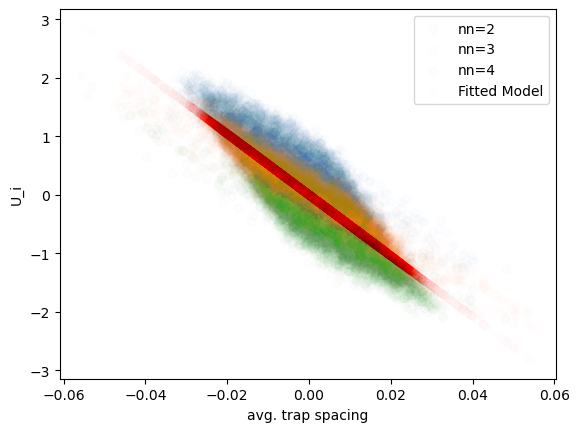

In [70]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(X[:, nno == i], Y[:, nno == i].flatten(), alpha=1e-2, label=f"nn={i}")
# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", alpha=2e-3)

plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

This dependence is better than pure total trap depth.

## V_tot + trap neighbor number

In [2]:
X = dat["V_tot"][mask]
Y = Vi[mask]

In [3]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr


nno = nneighbor(width, height)
avgr = avg_trap_spacing(np.arange(width * height)).T

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(torch.randn((2,)))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter
        self.c = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        return (
            self.a[0] * (-x["vtot"] + self.a[1] * np.sqrt(x["vtot"]))
            + self.b * x["nn"][None]
            + self.c
        )


# Convert data to torch tensors
# X_torch = torch.tensor(np.log(X), dtype=torch.float32)
# Y_torch = torch.tensor(np.log(Y), dtype=torch.float32)
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
# X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nno, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a
bx = model.b.item()
c = model.c.item()

print(f"Model: Y = {a[0]} * (-X + {a[1]} * sqrt(X)) + {bx} * nno + {c}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 23.7661
Epoch [2/1000], Loss: 0.2905
Epoch [3/1000], Loss: 0.0935
Epoch [4/1000], Loss: 0.0931
Epoch [5/1000], Loss: 0.0931
Final Loss: 0.0931
Model: Y = 1.1099772453308105 * (-X + -79.84925079345703 * sqrt(X)) + -0.4706364572048187 * nno + 55.486549377441406
R^2 Score: 0.9069467413971818


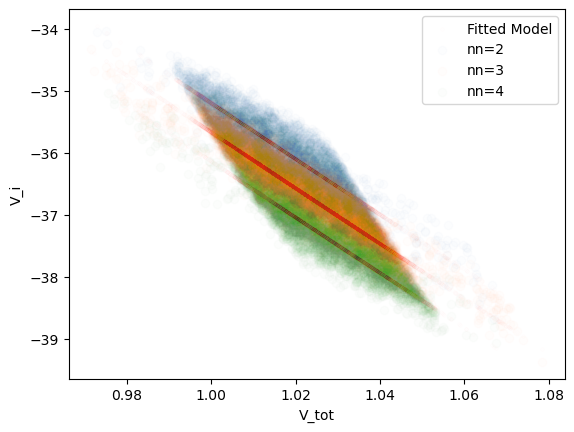

In [5]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=2e-3)
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(X[:, nno == i], Y[:, nno == i].flatten(), alpha=1e-2, label=f"nn={i}")

plt.xlabel("V_tot")
plt.ylabel("V_i")
plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

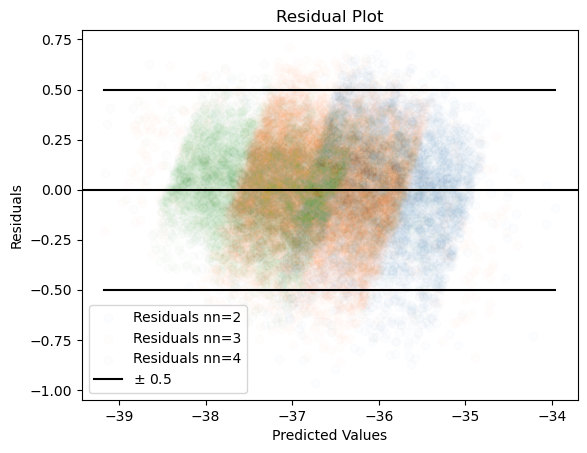

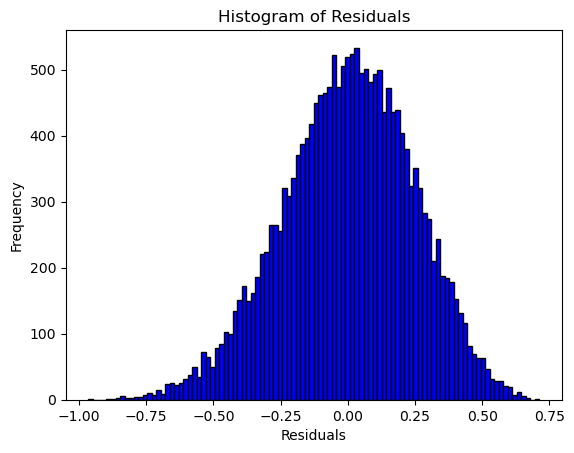

In [34]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=1e-2,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.5 * np.ones_like(x), color="k", label="$\pm$ 0.5")
plt.plot(x, -0.5 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np.flatten(), bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

### (Depracated) Relative trap depth

In [77]:
Voff = dat["V_offset"][mask]
tc = dat["trap_centers"][mask]
X = np.array(list(map(tot_trap_depth, Voff, tc)))
X = X - np.mean(X, axis=1)[:, None]
Y = Vi[mask]

In [78]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(torch.randn(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter
        self.c = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter

    def forward(self, x):
        return self.a * x["vtot"] + self.b * x["nn"][None] + self.c


# Convert data to torch tensors
# X_torch = torch.tensor(np.log(X), dtype=torch.float32)
# Y_torch = torch.tensor(np.log(Y), dtype=torch.float32)
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
# X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nno, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new
        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
bx = model.b.item()
c = model.c.item()

print(f"Model: Y = {a} X + {bx} * nno + {c}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.4110
Epoch [2/1000], Loss: 0.0911
Epoch [3/1000], Loss: 0.0911
Epoch [4/1000], Loss: 0.0911
Final Loss: 0.0911
Model: Y = -44.65470886230469 X + -0.4719489812850952 * nno + 1.4158397912979126
R^2 Score: 0.908874184613004


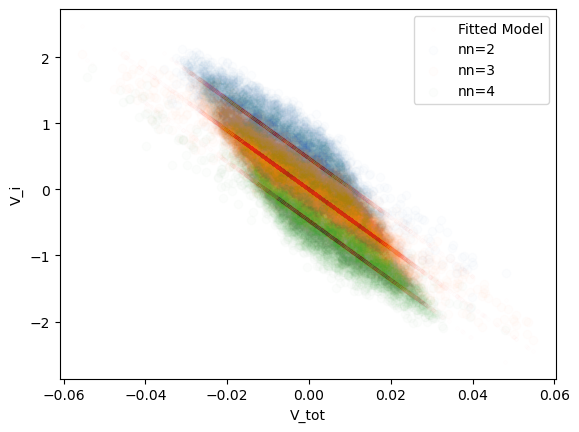

In [79]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=2e-3)
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(X[:, nno == i], Y[:, nno == i].flatten(), alpha=1e-2, label=f"nn={i}")

plt.xlabel("V_tot")
plt.ylabel("V_i")
plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

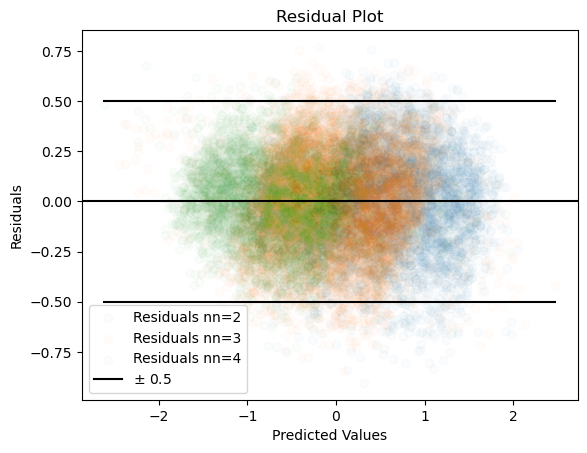

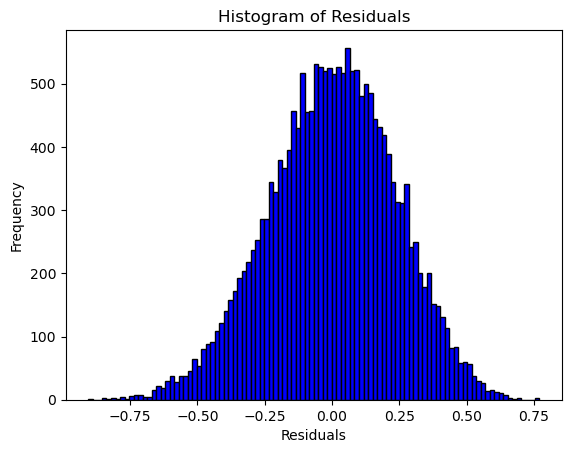

In [80]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=2e-2,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.5 * np.ones_like(x), color="k", label="$\pm$ 0.5")
plt.plot(x, -0.5 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np.flatten(), bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

### x y neighbor number

In [81]:
Voff = dat["V_offset"][mask]
tc = dat["trap_centers"][mask]
X = np.array(list(map(tot_trap_depth, Voff, tc)))
X = X - np.mean(X, axis=1)[:, None]
Y = Vi[mask]

In [82]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbors(index, width, height):
    if isinstance(index, Iterable):
        return np.array([nneighbors(i, width, height) for i in index])
    x = index % width
    y = index // height
    count = np.zeros(2, dtype=int)
    count[0] += 1 if x > 0 else 0  # left neighbor
    count[0] += 1 if x < width - 1 else 0  # right neighbor
    count[1] += 1 if y > 0 else 0  # top neighbor
    count[1] += 1 if y < height - 1 else 0  # bottom neighbor
    return count


nnxy = nneighbors(np.arange(16), width, height).T


def spacings(index, width, height):
    if isinstance(index, Iterable):
        return np.array([spacings(i, width, height) for i in index])
    x = index % width
    y = index // height
    xm1 = x - 1 if x > 0 else 0
    xp1 = x + 1 if x < width - 1 else width - 1
    ym1 = y - 1 if y > 0 else 0
    yp1 = y + 1 if y < height - 1 else height - 1
    return [y * width + xm1, y * width + xp1, ym1 * width + x, yp1 * width + x]


nidx = spacings(np.arange(16), width, height).T
xspacing = dat["rij"][mask][:, nidx[0], nidx[1]] / nnxy[0][None]
yspacing = dat["rij"][mask][:, nidx[2], nidx[3]] / nnxy[1][None]
spacing = [xspacing, yspacing]

In [83]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(
            torch.randn((), dtype=torch.float64)
        )  # Initialize the 'a' parameter
        self.b = nn.Parameter(
            torch.randn((2,), dtype=torch.float64)
        )  # Initialize the 'b' parameter
        self.c = nn.Parameter(
            torch.randn((), dtype=torch.float64)
        )  # Initialize the 'b' parameter

    def forward(self, x):
        # ax = self.a[0] * x["nn"][0] + self.a[1]
        # ay = self.a[2] * x["nn"][1] + self.a[3]
        # return ax[None] * ay[None] * x["vtot"] + self.b[None] @ x["nn"] + self.c
        return self.a * x["vtot"] + self.b[None] @ x["nn"] + self.c


# Convert data to torch tensors
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
# X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nnxy, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new
        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
bx = model.b
c = model.c.item()

print(f"Model: Y = {a} * X + [{bx[0]} {bx[1]}] * nn + {c}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.1045
Epoch [2/1000], Loss: 0.0891
Epoch [3/1000], Loss: 0.0891
Epoch [4/1000], Loss: 0.0891
Final Loss: 0.0891
Model: Y = -44.45666696909025 * X + [-0.42312603339261873 -0.5227220789157035] * nn + 1.4187695436053531
R^2 Score: 0.9109091352574871


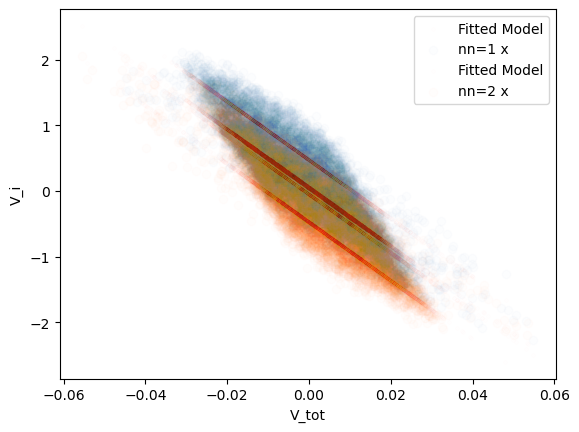

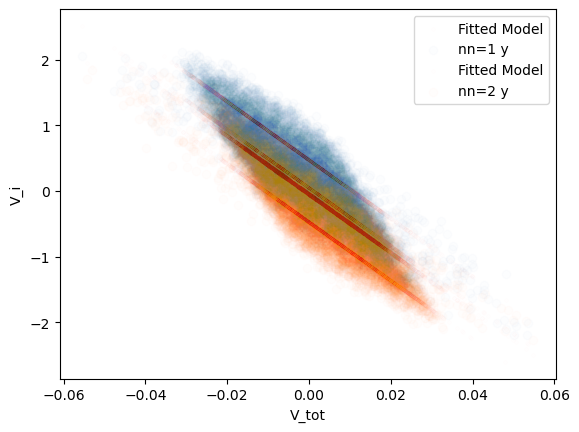

In [87]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
for j in range(2):
    plt.figure()
    for i in [1, 2]:
        # Plotting the model's predictions
        plt.scatter(
            X[:, nnxy[j] == i],
            predicted[:, nnxy[j] == i].flatten(),
            color="r",
            label="Fitted Model",
            marker=".",
            alpha=2e-3,
        )
        plt.scatter(
            X[:, nnxy[j] == i],
            Y[:, nnxy[j] == i].flatten(),
            alpha=1e-2,
            label=f"nn={i} {['x', 'y'][j]}",
        )
    plt.xlabel("V_tot")
    plt.ylabel("V_i")
    plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

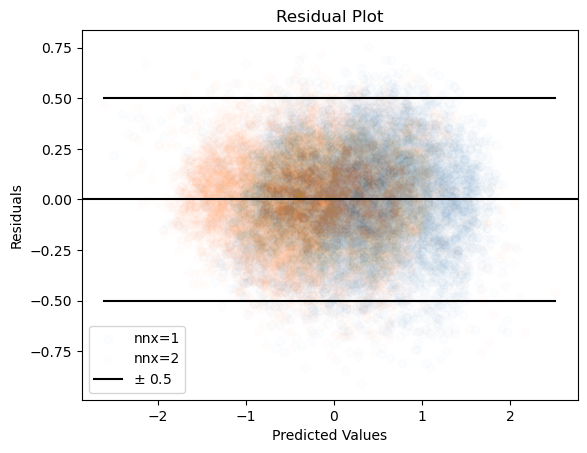

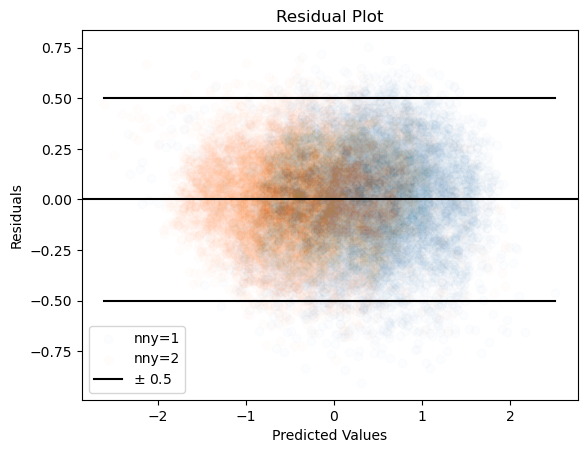

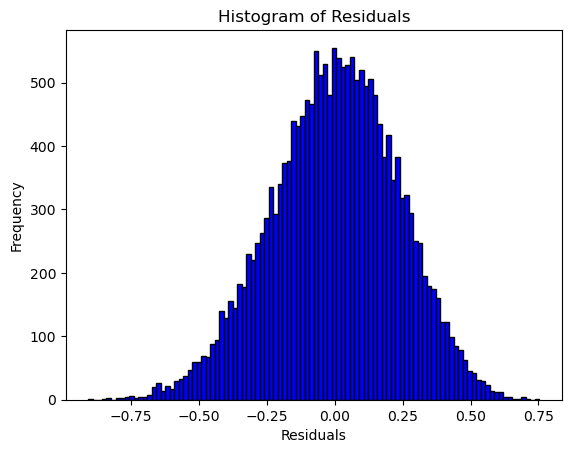

In [91]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)

# Plotting residuals
for j in range(2):
    plt.figure()
    # Plotting the original data
    for i in [1, 2]:
        plt.scatter(
            predictions_np[:, nnxy[j] == i].flatten(),
            residuals_np[:, nnxy[j] == i].flatten(),
            # color="blue",
            alpha=1e-2,
            label=f"nn{['x', 'y'][j]}={i}",
        )
    plt.axhline(y=0, color="k", linestyle="-")
    plt.plot(x, 0.5 * np.ones_like(x), color="k", label="$\pm$ 0.5")
    plt.plot(x, -0.5 * np.ones_like(x), color="k")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np.flatten(), bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

## Model with above and trap spacing

In [35]:
X = dat["V_tot"][mask]
Y = Vi[mask]

In [36]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr


nno = nneighbor(width, height)
avgr = avg_trap_spacing(np.arange(width * height)).T

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.a = nn.Parameter(torch.randn((2,)))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn((2,)))  # Initialize the 'b' parameter
        self.c = nn.Parameter(torch.randn((2,)))  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        a = self.a[0] * (-x["vtot"] + self.a[1] * np.sqrt(x["vtot"]))
        b = self.b[0] * x["nn"][None] + self.b[1]
        c = self.c[0] * x["nn"][None] + self.c[1]
        return a + b * x["avgr"] + c


# Convert data to torch tensors
# X_torch = torch.tensor(np.log(X), dtype=torch.float32)
# Y_torch = torch.tensor(np.log(Y), dtype=torch.float32)
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nno, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        # # Forward pass
        # outputs = model(X_torch)
        # loss = criterion(outputs, Y_torch)
        # loss_new = loss.item()
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
        # # Backward and optimize
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a
bx = model.b
c = model.c

print(
    f"Exponential model: Y = {a[0]} * (- X + {a[1]} * sqrt(X)) + ({bx[0]} * nno + {bx[1]}) * avgr + ({c[0]} * nno + {c[1]})"
)
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.3160
Epoch [2/1000], Loss: 0.0240
Epoch [3/1000], Loss: 0.0084
Epoch [4/1000], Loss: 0.0083
Epoch [5/1000], Loss: 0.0083
Epoch [6/1000], Loss: 0.0083
Epoch [7/1000], Loss: 0.0083
Final Loss: 0.0083
Exponential model: Y = 6.568325519561768 * (- X + -10.488484382629395 * sqrt(X)) + (1.632949709892273 * nno + 3.3245930671691895) * avgr + (-3.0947108268737793 * nno + 36.01438903808594)
R^2 Score: 0.9917179166106418


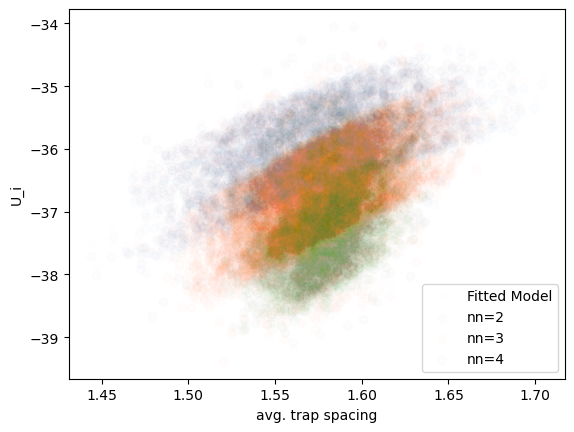

In [38]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the model's predictions
plt.scatter(avgr, predicted, color="red", label="Fitted Model", alpha=2e-3)

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        avgr[:, nno == i], Y[:, nno == i].flatten(), alpha=1e-2, label=f"nn={i}"
    )

plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

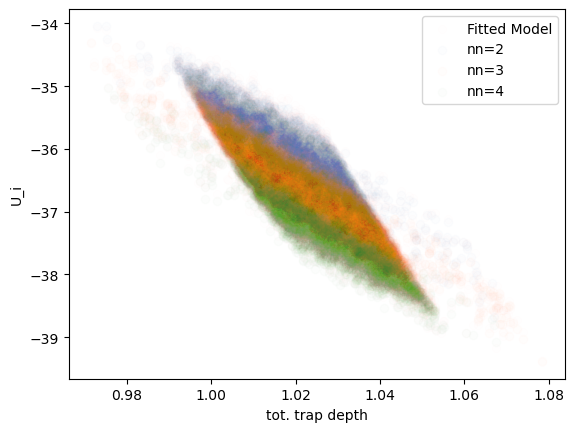

In [39]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", alpha=2e-3)

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(X[:, nno == i], Y[:, nno == i].flatten(), alpha=1e-2, label=f"nn={i}")

plt.xlabel("tot. trap depth")
plt.ylabel("U_i")
plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

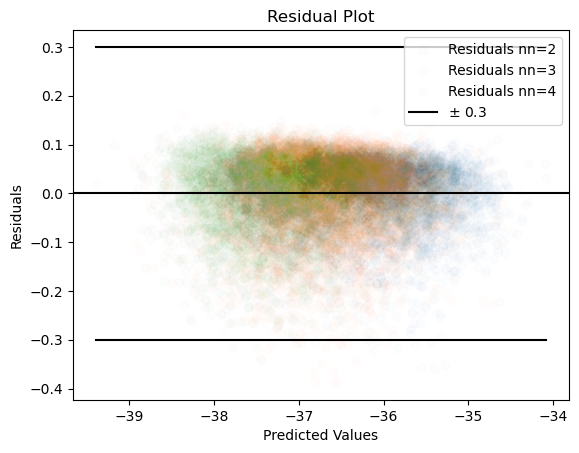

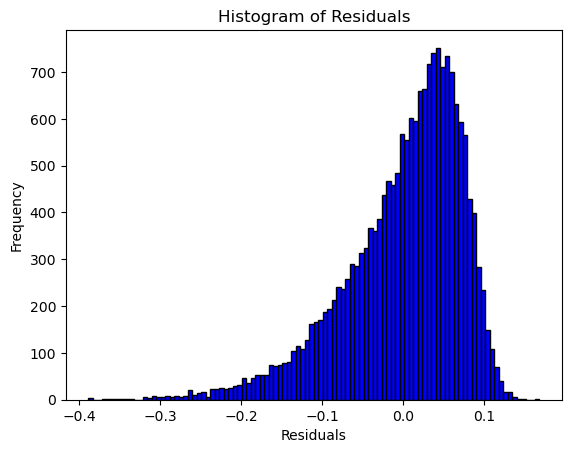

In [40]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=1e-2,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.3 * np.ones_like(x), color="k", label="$\pm$ 0.3")
plt.plot(x, -0.3 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np.flatten(), bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

### Relative trap depth

In [11]:
Voff = dat["V_offset"][mask]
tc = dat["trap_centers"][mask]
X = np.array(list(map(tot_trap_depth, Voff, tc)))
X = X - np.mean(X, axis=1)[:, None]
Y = Vi[mask]

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.a = nn.Parameter(torch.randn(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn((2,)))  # Initialize the 'b' parameter
        self.c = nn.Parameter(torch.randn((2,)))  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        a = self.a * x["vtot"]
        b = self.b[0] * x["nn"][None] + self.b[1]
        c = self.c[0] * x["nn"][None] + self.c[1]
        return a + b * x["avgr"] + c


# Convert data to torch tensors
# X_torch = torch.tensor(np.log(X), dtype=torch.float32)
# Y_torch = torch.tensor(np.log(Y), dtype=torch.float32)
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nno, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
bx = model.b
c = model.c

print(f"Model: Y = {a} * X + ({bx[0]} * nno + {bx[1]}) * avgr + {c[0]} * nno + {c[1]}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.5809
Epoch [2/1000], Loss: 0.0137
Epoch [3/1000], Loss: 0.0133
Epoch [4/1000], Loss: 0.0133
Final Loss: 0.0133
Model: Y = -40.67880630493164 * X + (1.5553295612335205 * nno + 2.9900264739990234) * avgr + -2.9700324535369873 * nno + -3.1613504886627197
R^2 Score: 0.9867450046129073


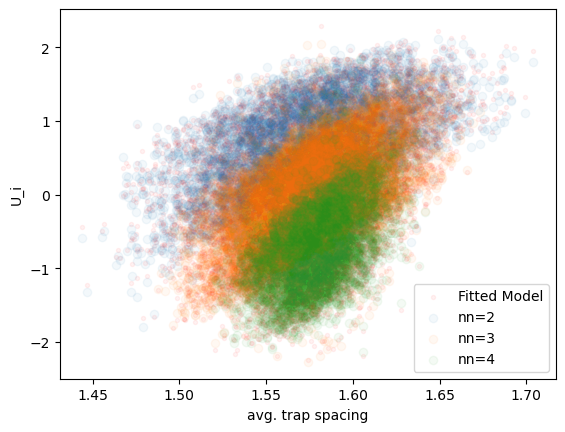

In [13]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the model's predictions
plt.scatter(avgr, predicted, color="red", label="Fitted Model", marker=".", alpha=5e-2)

# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        avgr[:, nno == i], Y[:, nno == i].flatten(), alpha=5e-2, label=f"nn={i}"
    )

plt.xlabel("avg. trap spacing")
plt.ylabel("U_i")
plt.legend()

Text(0.5, 1.0, 'Histogram of Residuals')

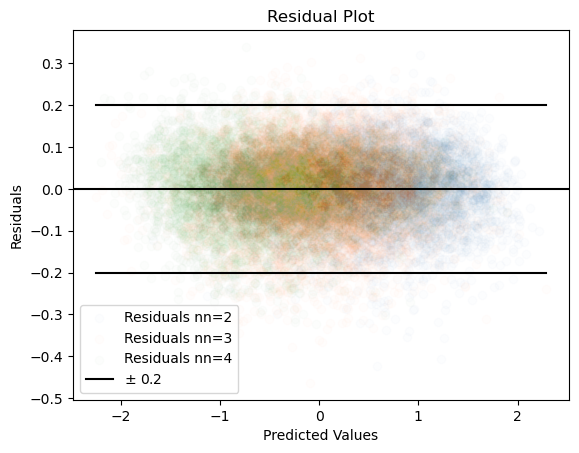

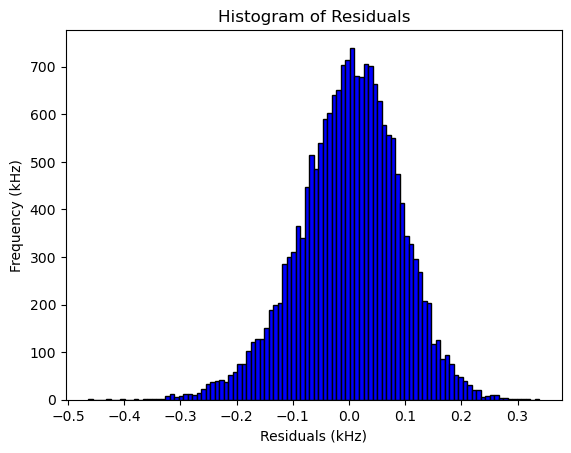

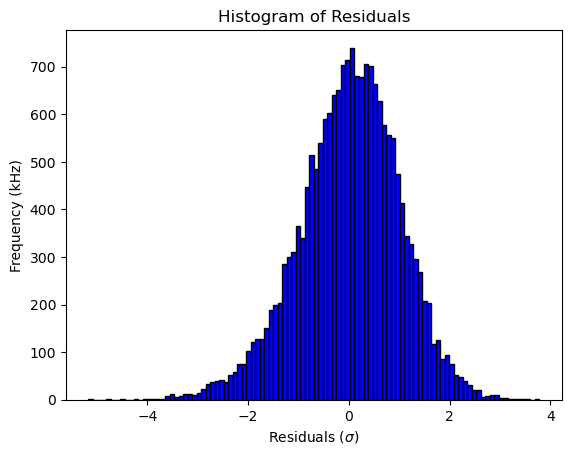

In [24]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()
sigma = np.std(residuals_np)

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=1e-2,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.2 * np.ones_like(x), color="k", label="$\pm$ 0.2")
plt.plot(x, -0.2 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np.flatten(), bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals (kHz)")
plt.ylabel("Frequency (kHz)")
plt.title("Histogram of Residuals")

# Optional: Histogram of Residuals ratio to sigma
plt.figure()
plt.hist(residuals_np.flatten() / sigma, bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals ($\sigma$)")
plt.ylabel("Frequency (kHz)")
plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")

THe data range is roughly from -2 to 2 and the residual is around +-0.2. So R2 is this squared  ~0.99.

### x y separate spacing

In [41]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbors(index, width, height):
    if isinstance(index, Iterable):
        return np.array([nneighbors(i, width, height) for i in index])
    x = index % width
    y = index // height
    count = np.zeros(2, dtype=int)
    count[0] += 1 if x > 0 else 0  # left neighbor
    count[0] += 1 if x < width - 1 else 0  # right neighbor
    count[1] += 1 if y > 0 else 0  # top neighbor
    count[1] += 1 if y < height - 1 else 0  # bottom neighbor
    return count


nnxy = nneighbors(np.arange(16), width, height).T


def spacings(index, width, height):
    if isinstance(index, Iterable):
        return np.array([spacings(i, width, height) for i in index])
    x = index % width
    y = index // height
    xm1 = x - 1 if x > 0 else 0
    xp1 = x + 1 if x < width - 1 else width - 1
    ym1 = y - 1 if y > 0 else 0
    yp1 = y + 1 if y < height - 1 else height - 1
    return [y * width + xm1, y * width + xp1, ym1 * width + x, yp1 * width + x]


nidx = spacings(np.arange(16), width, height).T
xspacing = dat["rij"][mask][:, nidx[0], nidx[1]] / nnxy[0][None]
yspacing = dat["rij"][mask][:, nidx[2], nidx[3]] / nnxy[1][None]
spacing = [xspacing, yspacing]

In [42]:
X = dat["V_tot"][mask]
Y = Vi[mask]

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(
            torch.randn((2,), dtype=torch.float64)
        )  # Initialize the 'a' parameter
        self.b = nn.Parameter(
            torch.randn((4,), dtype=torch.float64)
        )  # Initialize the 'b' parameter
        self.c = nn.Parameter(
            torch.randn((4,), dtype=torch.float64)
        )  # Initialize the 'b' parameter

    def forward(self, x):
        aterm = self.a[0] * (-x["vtot"][0] + self.a[1] * np.sqrt(x["vtot"][0]))
        bx = self.b[0] * x["nn"][0][None] + self.b[1]
        xterm = bx * x["spacing"][0] + self.c[0] * x["nn"][0][None] + self.c[1]
        by = self.b[2] * x["nn"][1][None] + self.b[3]
        yterm = by * x["spacing"][1] + self.c[2] * x["nn"][1][None] + self.c[3]
        return aterm + xterm + yterm


# Convert data to torch tensors
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
X_torch["spacing"] = torch.tensor(spacing, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nnxy, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new
        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a
b = model.b
c = model.c

print(
    f"Model: Y = {a[0]} * (-X + {a[1]} * sqrt(X)) \n \
    + (({b[0]} * nnx + {b[1]}) * spacingx + {c[0]} * nnx + {c[1]}) \n \
    + (({b[2]} * nny + {b[3]}) * spacingy + {c[2]} * nny + {c[3]})"
)
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.9712
Epoch [2/1000], Loss: 0.4128
Epoch [3/1000], Loss: 0.4048
Epoch [4/1000], Loss: 0.4048
Epoch [5/1000], Loss: 0.4048
Final Loss: 0.4048
Model: Y = 0.037911107841646606 * (-X + tensor([4.1977], dtype=torch.float64, grad_fn=<IndexBackward0>) * sqrt(X)) + ((2.4982713919247854 * nnx + 1.5257829748424572) * spacingx + -4.6427969909725055 * nnx + -19.97513816265066) + ((3.7614639955488856 * nny + 1.498004384209103) * spacingy + -6.672559931136072 * nny + -19.374118061336592)
R^2 Score: 0.5952116733874435


Text(0.5, 1.0, 'Histogram of Residuals')

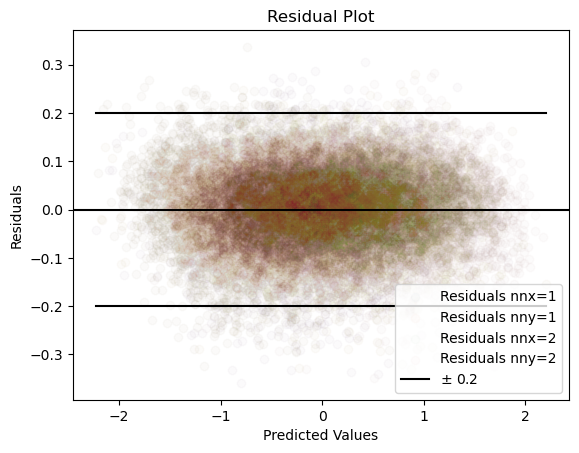

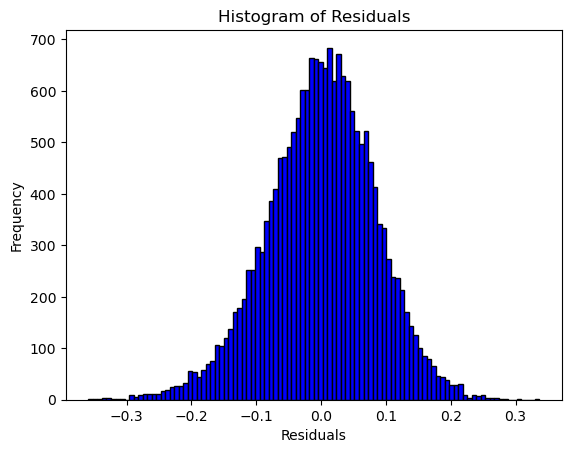

In [82]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [1, 2]:
    for j in range(2):
        plt.scatter(
            predictions_np[:, nnxy[j] == i].flatten(),
            residuals_np[:, nnxy[j] == i].flatten(),
            # color="blue",
            alpha=1e-2,
            label=f"Residuals nn{['x', 'y'][j]}={i}",
        )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.2 * np.ones_like(x), color="k", label="$\pm$ 0.2")
plt.plot(x, -0.2 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(residuals_np.flatten(), bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

#### TEST: Vtot + f(spacing) or Vtot * f(spacing)?

In [87]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(
            torch.randn((), dtype=torch.float64)
        )  # Initialize the 'a' parameter
        self.b = nn.Parameter(
            torch.randn((4,), dtype=torch.float64)
        )  # Initialize the 'b' parameter
        self.c = nn.Parameter(
            torch.randn((4,), dtype=torch.float64)
        )  # Initialize the 'b' parameter

    def forward(self, x):
        # ax = self.a[0] * x["nn"][0] + self.a[1]
        # ay = self.a[2] * x["nn"][1] + self.a[3]
        # return ax[None] * ay[None] * x["vtot"] + self.b[None] @ x["nn"] + self.c
        bx = self.b[0] * x["nn"][0][None] + self.b[1]
        xterm = bx * x["spacing"][0] + self.c[0] * x["nn"][0][None] + self.c[1]
        by = self.b[2] * x["nn"][1][None] + self.b[3]
        yterm = by * x["spacing"][1] + self.c[2] * x["nn"][1][None] + self.c[3]
        return x["vtot"] * (xterm + yterm) + self.a


# Convert data to torch tensors
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
X_torch["spacing"] = torch.tensor(spacing, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nnxy, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new
        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
b = model.b
c = model.c

print(
    f"Model: Y = ((({b[0]} * nnx + {b[1]}) * spacingx + {c[0]} * nnx + {c[1]}) + (({b[2]} * nny + {b[3]}) * spacingy + {c[2]} * nny + {c[3]})) * X + {a}"
)
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.2727
Epoch [2/1000], Loss: 0.2582
Epoch [3/1000], Loss: 0.2514
Epoch [4/1000], Loss: 0.2514
Epoch [5/1000], Loss: 0.2514
Final Loss: 0.2514
Model: Y = (((25.008576662413258 * nnx + -51.578945170138994) * spacingx + -38.894916450969646 * nnx + 294.2714547566972) + ((265.2559381323055 * nny + -363.08582737038523) * spacingy + -410.50649974154516 * nny + 296.19654214680384)) * X + -0.0043229888488267336
R^2 Score: 0.7486375804767178


In [88]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class PotentialModel(nn.Module):
    def __init__(self):
        super(PotentialModel, self).__init__()
        self.a = nn.Parameter(
            torch.randn((), dtype=torch.float64)
        )  # Initialize the 'a' parameter
        self.b = nn.Parameter(
            torch.randn((4,), dtype=torch.float64)
        )  # Initialize the 'b' parameter
        self.c = nn.Parameter(
            torch.randn((4,), dtype=torch.float64)
        )  # Initialize the 'b' parameter

    def forward(self, x):
        # ax = self.a[0] * x["nn"][0] + self.a[1]
        # ay = self.a[2] * x["nn"][1] + self.a[3]
        # return ax[None] * ay[None] * x["vtot"] + self.b[None] @ x["nn"] + self.c
        bx = self.b[0] * x["nn"][0][None] + self.b[1]
        xterm = bx * x["spacing"][0] + self.c[0] * x["nn"][0][None] + self.c[1]
        by = self.b[2] * x["nn"][1][None] + self.b[3]
        yterm = by * x["spacing"][1] + self.c[2] * x["nn"][1][None] + self.c[3]
        return x["vtot"] * (xterm * yterm) + self.a


# Convert data to torch tensors
X_torch = {}
X_torch["vtot"] = torch.tensor(X, dtype=torch.float64)
X_torch["spacing"] = torch.tensor(spacing, dtype=torch.float64)
X_torch["nn"] = torch.tensor(nnxy, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = PotentialModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new
        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
b = model.b
c = model.c

print(
    f"Model: Y = ((({b[0]} * nnx + {b[1]}) * spacingx + {c[0]} * nnx + {c[1]}) * (({b[2]} * nny + {b[3]}) * spacingy + {c[2]} * nny + {c[3]})) * X + {a}"
)
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.2580
Epoch [2/1000], Loss: 0.2519
Epoch [3/1000], Loss: 0.2508
Epoch [4/1000], Loss: 0.2508
Epoch [5/1000], Loss: 0.2508
Final Loss: 0.2508
Model: Y = (((-15.292748026070743 * nnx + 22.772851351263647) * spacingx + 24.269629988057552 * nnx + -27.833007411196117) * ((30.779675942300074 * nny + -42.778382090574986) * spacingy + -47.590622770071526 * nny + 59.834457508062194)) * X + -0.005304894641865975
R^2 Score: 0.7492038527196837


The sum of factor terms is better than the product of factor terms.

## Harmonic trap approximation model

### Model form

Using 1D harmonic approximation, we can write the harmonic potential near the minimal point

$$ V(r) = - A (r - \frac{B}{2 A})^2 + Dz^2 + \frac{B^2}{4 A} - C $$

where,

$$ A = - \frac{2V_0}{w^2} + \sum_i \frac{2V_i (4a^2_i - w^2)}{w^4} e^{-2a^2_i / w^2} <0 $$

$$ B = \sum_i \frac{4V_i a_i}{w^2} e^{-2a^2_i / w^2} $$

$$ C = V_0 + \sum_i V_i e^{-2a^2_i / w^2} = V_{tot} $$

where $a_i$ is the linear distance between the trap and the $i$-th trap. 

NOTE: why 1D? 
1. 1D can avoid the annoying $xy$ cross term in 2rd order potential, given by expanding $e^{-\bm{a_i\cdot r}}$.
2. The $z$ term will give a quadratic $Dz^2$ term. It doesn't affect constant term, and

$$ D = \frac{V_0}{z^2_R} - \sum_i \frac{V_i (2a^2_i - w^2)}{w^2z^2_R} e^{-2a^2_i / w^2} $$

is in the similar form of $A$. At this step we just ignore it.

### Simplify parameters

$C = V_{tot}$ is the total trap depth. And $A$ is also related by

$$ A = -\frac{2V_{tot}}{w^2} + \sum_i \frac{8 V_i a^2_i}{w^4} e^{-2a^2_i / w^2} $$

And finally,

$$ \frac{B^2}{4 A} = \frac{2 \sum_{ij} V_i a_i V_j a_j e^{-2(a^2_i + a^2_j) / w^2}}{-w^2V_{tot} + \sum_i 4 V_i a^2_i e^{-2a^2_i / w^2}} $$

In principle, we can expand the above by the fluctuating $V_i=V_0 + \delta V_i$ and $a_i=\bar{a} + \delta a_i$, then get the dependence order by order. If we only expand to the 1st order, since we know $\sum_i \delta a_i = 0$, then we can write

$$ A \approx \frac{8 \bar{a}^2 (V_{tot} - V_0) - 2 w^2 V_{tot}}{w^4} $$

$$ B \approx \frac{4 \bar{a} (V_{tot} - V_0)}{w^2} $$

$$ \frac{B^2}{4 A} \approx \frac{2 \bar{a}^2 (V_{tot} - V_0)^2}{4 \bar{a}^2 (V_{tot} - V_0) - w^2 V_{tot}} $$

NOTE:
1. although $V_{tot} - V_0 = \sum_i V_i e^{-a^2_i / 2w^2}$ is small due to small $e^{-a^2_i / 2w^2}$, since all the othre terms has this factor they are still smaller and controlled by $\delta$.
2. so $V_{tot} - V_0$ is the only term containing 1st order correction and partial higher order terms given by the exponential, but the latter should only contribute to the accuracy of the model.


We derive from this the onsite potential, i.e. GS energy in the approximated 'isotropic' 3D harmonic trap

$$ -\mu = -C + \frac{B^2}{4 A} + 3\hbar \sqrt{\frac{-A}{2m}} $$

and approximate it as

$$ -\mu \approx \frac{2 \bar{a}^2 (V_{tot} - V_0)^2 - 4 V_{tot} \bar{a}^2 (V_{tot} - V_0) + w^2 V^2_{tot}}{4 \bar{a}^2 (V_{tot} - V_0) - w^2 V_{tot}} + 3\hbar \sqrt{\frac{w^2 V_{tot} - 4 \bar{a}^2 (V_{tot} - V_0)}{mw^4}} $$

$$ \approx -\frac{(w^2 - 2 \bar{a}^2) V^2_{tot} + 2 \bar{a}^2 V_0^2}{(w^2 - 4 \bar{a}^2) V_{tot} + 4 \bar{a}^2 V_0} + \sqrt{\frac{9 \hbar^2}{m w^4}} \sqrt{(w^2 - 4 \bar{a}^2) V_{tot} + 4 \bar{a}^2 V_0} $$

Then we can fit the data with this model. The neighboring number is encoded by difference between $V_{tot}$ and $V_0$.

$$ -\mu = -c_1 \frac{(b_2 - \bar{a}^2) V^2_{tot} + \bar{a}^2 V_0^2}{(b_1 - \bar{a}^2) V_{tot} + \bar{a}^2 V_0} + c_2 \sqrt{(b_1 - \bar{a}^2) V_{tot} + \bar{a}^2 V_0} $$

From calculation, we can derive the theoretical value for $b_1, b_2, c_1, c_2$. Listed below:

$$ b_1 = \frac{w^2}{4} = 0.25 (\mathrm{\mu m^2}) $$

$$ b_2 = \frac{w^2}{2} = 0.5 (\mathrm{\mu m^2}) $$

$$ c_1 = \frac{V_\text{unit} \equiv 50 \mathrm{kHz}}{2} = 25 (\mathrm{kHz}) $$

$$ c_2 = 2 \sqrt{\frac{9 \hbar^2 V_\text{unit}}{m w^4}} = 55.0661 (\mathrm{kHz}) $$

In [2]:
Voff = dat["V_offset"][mask]
Vtot = dat["V_tot"][mask]
Y = Vi[mask]

In [4]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr


nno = nneighbor(width, height)
avgr = avg_trap_spacing(np.arange(width * height)).T

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.a = nn.Parameter(0.25 * torch.ones(1))  # Initialize the 'a' parameter
        self.b = nn.Parameter(0.5 * torch.ones(1))  # Initialize the 'b' parameter
        self.c = nn.Parameter(
            torch.tensor([25.0, 55.0])
        )  # Initialize the 'b' parameter

    def forward(self, x):
        # return self.a * x + self.
        a = (self.a - x["avgr"] ** 2) * x["vtot"] + x["avgr"] ** 2 * x["voff"]
        b = (self.b - x["avgr"] ** 2) * x["vtot"] ** 2 + x["avgr"] ** 2 * x["voff"] ** 2
        return -self.c[0] * b / a + self.c[1] * torch.sqrt(a)


# Convert data to torch tensors
X_torch = {}
X_torch["vtot"] = torch.tensor(Vtot, dtype=torch.float64)
X_torch["voff"] = torch.tensor(Voff, dtype=torch.float64)
X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

a = model.a.item()
b = model.b.item()
c = model.c

print(f"Model: Y = {a} {b} {c[0]} {c[1]}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 2.4486
Epoch [2/1000], Loss: 0.0185
Epoch [3/1000], Loss: 0.0024
Epoch [4/1000], Loss: 0.0024
Epoch [5/1000], Loss: 0.0024
Epoch [6/1000], Loss: 0.0024
Epoch [7/1000], Loss: 0.0024
Final Loss: 0.0024
Model: Y = 0.15408702194690704 0.2911047339439392 25.86914825439453 37.56966018676758
R^2 Score: 0.997575148584322


Text(0.5, 1.0, 'Histogram of Residuals')

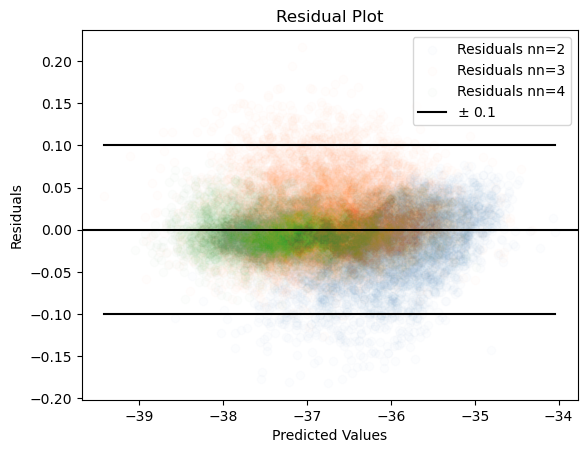

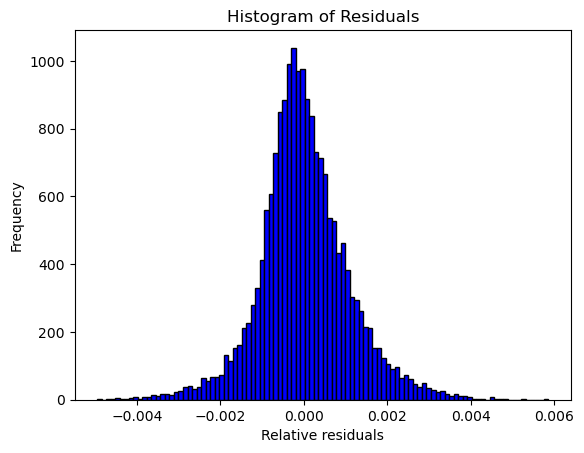

In [8]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=1e-2,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.1 * np.ones_like(x), color="k", label="$\pm$ 0.1")
plt.plot(x, -0.1 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

This model has been pretty accurate by its relative precision to the predicted values. The model works since it captures the trap center propterty.

We notice that the nnn=2 is overestimated and nnn=3 is underestimated. Only nnn=4 is relatively well estimated.

Note that this model doesn't take fully into account the number of n.n. This is only included in the total trap depth. We may need a correction on that.

## Harmonic approximation but with $z$ direction anisotropy

We redo everything as above, but with $z$ direction anisotropy. The model is now

$$ V(r) = A (r + \frac{B}{2 A})^2 + Dz^2 - \frac{B^2}{4 A} - C $$

where,

$$ A = \frac{2V_0}{w^2} - \sum_i \frac{2V_i (4a^2_i - w^2)}{w^4} e^{-2a^2_i / w^2} > 0 $$

$$ B = \sum_i \frac{4V_i a_i}{w^2} e^{-2a^2_i / w^2} $$

$$ C = V_0 + \sum_i V_i e^{-2a^2_i / w^2} = V_{tot} $$

$$ D = \frac{V_0}{z^2_R} - \sum_i \frac{V_i (2a^2_i - w^2)}{w^2z^2_R} e^{-2a^2_i / w^2} > 0 $$


Therefore, the GS level is given by

$$ -\mu = - C - \frac{B^2}{4 A} + 2\hbar \sqrt{\frac{A}{2m}} + \hbar \sqrt{\frac{D}{2m}} $$

$$ A \approx \frac{2 w^2 V_{tot} - 8 \bar{a}^2 (V_{tot} - V_0)}{w^4} $$

$$ B \approx \frac{4 \bar{a} (V_{tot} - V_0)}{w^2} $$

$$ \frac{B^2}{4 A} \approx \frac{2 \bar{a}^2 (V_{tot} - V_0)^2}{w^2 V_{tot} - 4 \bar{a}^2 (V_{tot} - V_0)} $$

$$ D \approx \frac{w^2 V_{tot} - 2 \bar{a}^2 (V_{tot} - V_0)}{w^2 z^2_R} $$

and approximate it as

$$ -\mu \approx -\frac{(w^2 - 2 \bar{a}^2) V^2_{tot} + 2 \bar{a}^2 V_0^2}{(w^2 - 4 \bar{a}^2) V_{tot} + 4 \bar{a}^2 V_0} + \sqrt{\frac{4 \hbar^2}{m w^4}} \sqrt{(w^2 - 4 \bar{a}^2) V_{tot} + 4 \bar{a}^2 V_0} + \sqrt{\frac{\hbar^2}{2 m w^2 z^2_R}} \sqrt{(w^2 - 2 \bar{a}^2) V_{tot} + 2 \bar{a}^2 V_0} $$

Then we can fit the data with this model. The neighboring number is encoded by difference between $V_{tot}$ and $V_0$.

$$ -\mu = -c_1 \frac{(b_2 - \bar{a}^2) V^2_{tot} + \bar{a}^2 V_0^2}{(b_1 - \bar{a}^2) V_{tot} + \bar{a}^2 V_0} + c_2 \sqrt{(b_1 - \bar{a}^2) V_{tot} + \bar{a}^2 V_0} + c_3 \sqrt{(b_2 - \bar{a}^2) V_{tot} + \bar{a}^2 V_0} $$

with 2 parameters modified

$$ c_2 = 4 \sqrt{\frac{\hbar^2 V_\text{unit}}{m w^4}} = 36.7107 (\mathrm{kHz}) $$

$$ c_3 = \sqrt{\frac{\hbar^2 V_\text{unit}}{m w^2 z^2_R}} = 2.29442 (\mathrm{kHz}) $$

In [9]:
Voff = dat["V_offset"][mask]
Vtot = dat["V_tot"][mask]
Y = Vi[mask]

In [10]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr


nno = nneighbor(width, height)
avgr = avg_trap_spacing(np.arange(width * height)).T

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.b = nn.Parameter(torch.tensor([0.25, 0.5]))  # Initialize the 'b' parameter
        self.c = nn.Parameter(
            torch.tensor([25.0, 36.7107, 2.29442])
        )  # Initialize the 'c' parameter

    def forward(self, x):
        a = (self.b[0] - x["avgr"] ** 2) * x["vtot"] + x["avgr"] ** 2 * x["voff"]
        b = (self.b[1] - x["avgr"] ** 2) * x["vtot"] + x["avgr"] ** 2 * x["voff"]
        c = (self.b[1] - x["avgr"] ** 2) * x["vtot"] ** 2 + x["avgr"] ** 2 * x[
            "voff"
        ] ** 2
        return (
            -self.c[0] * c / a + self.c[1] * torch.sqrt(a) + self.c[2] * torch.sqrt(b)
        )


# Convert data to torch tensors
X_torch = {}
X_torch["vtot"] = torch.tensor(Vtot, dtype=torch.float64)
X_torch["voff"] = torch.tensor(Voff, dtype=torch.float64)
X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

b = model.b
c = model.c

print(f"Model: b = {b[0]} {b[1]} c = {c[0]} {c[1]} {c[2]}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.4741
Epoch [2/1000], Loss: 0.0079
Epoch [3/1000], Loss: 0.0024
Epoch [4/1000], Loss: 0.0024
Epoch [5/1000], Loss: 0.0024
Epoch [6/1000], Loss: 0.0024
Epoch [7/1000], Loss: 0.0024
Epoch [8/1000], Loss: 0.0024
Final Loss: 0.0024
Model: b = 0.15489186346530914 0.2923521399497986 c = 26.105344772338867 37.77190399169922 0.5437327027320862
R^2 Score: 0.9975634903638552


Text(0.5, 1.0, 'Histogram of Residuals')

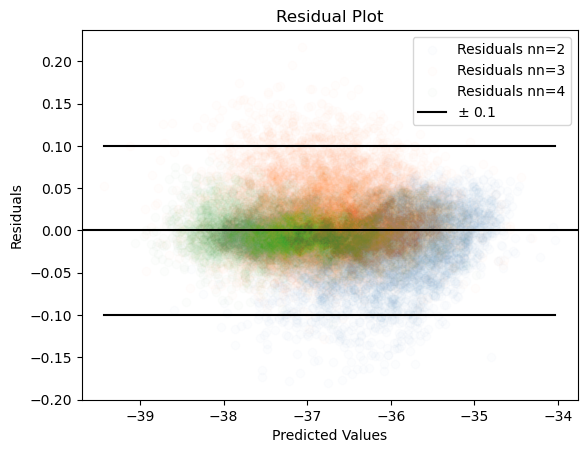

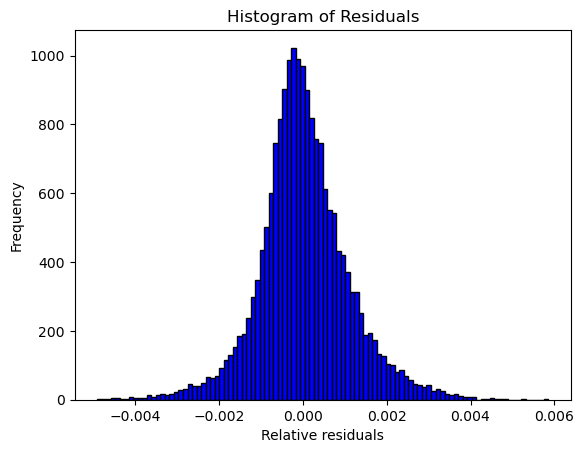

In [14]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=1e-2,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.1 * np.ones_like(x), color="k", label="$\pm$ 0.1")
plt.plot(x, -0.1 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

Not improved from the last model.

## More DoF?

We set factor in front of $V_{tot}$ and $V_0$ to be different. This effectively changes the weight of $V_{tot} - V_0$ i.e. make the dependence on `nnn` adjustable.

$$ -\mu = -c_1 \frac{(b_2 - \bar{a}^2) V^2_{tot} + k_2 \bar{a}^2 V_0^2}{(b_1 - \bar{a}^2) V_{tot} + k_1 \bar{a}^2 V_0} + c_2 \sqrt{(b_1 - \bar{a}^2) V_{tot} + k_1 \bar{a}^2 V_0} + c_3 \sqrt{(b_2 - \bar{a}^2) V_{tot} + k_2 \bar{a}^2 V_0} $$

And all $k_i$ are set to 1.

In [2]:
Voff = dat["V_offset"][mask]
Vtot = dat["V_tot"][mask]
Y = Vi[mask]

In [3]:
# Caluclate nearest neighbour numbers in a grid
width = 4
height = 4


def nneighbor(width, height):
    n = width * height
    nn = np.zeros(n, dtype=int)
    for i in range(n):
        x = i % width
        y = i // height
        count = 0

        if x > 0:
            count += 1  # left neighbor
        if x < width - 1:
            count += 1  # right neighbor
        if y > 0:
            count += 1  # top neighbor
        if y < height - 1:
            count += 1  # bottom neighbor

        nn[i] = count
    return nn


from typing import Iterable


def avg_trap_spacing(idx):
    # Calculate average trap spacing
    # idx = np.arange(16)
    if isinstance(idx, Iterable):
        return np.array([avg_trap_spacing(i) for i in idx])
    l1 = links[:, 0] == np.array([idx])[:, None].flatten()
    l2 = links[:, 1] == np.array([idx])[:, None].flatten()
    bonds = links[l1 | l2]
    avgr = np.mean(dat["rij"][mask][:, bonds[:, 0], bonds[:, 1]], axis=1)
    return avgr


nno = nneighbor(width, height)
avgr = avg_trap_spacing(np.arange(width * height)).T

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.b = nn.Parameter(
            torch.tensor([0.15408702194690704, 0.2911047339439392])
        )  # Initialize the 'b' parameter
        self.c = nn.Parameter(
            torch.tensor([25.86914825439453, 37.56966018676758])
        )  # Initialize the 'c' parameter
        self.k = nn.Parameter(torch.ones(2))  # Initialize the 'k' parameter

    def forward(self, x):
        # return self.a * x + self.
        a = (self.b[0] - x["avgr"] ** 2) * x["vtot"] + self.k[0] * x["avgr"] ** 2 * x[
            "voff"
        ]
        c = (self.b[1] - x["avgr"] ** 2) * x["vtot"] ** 2 + self.k[1] * x[
            "avgr"
        ] ** 2 * x["voff"] ** 2
        return -self.c[0] * c / a + self.c[1] * torch.sqrt(a)


# Convert data to torch tensors
X_torch = {}
X_torch["vtot"] = torch.tensor(Vtot, dtype=torch.float64)
X_torch["voff"] = torch.tensor(Voff, dtype=torch.float64)
X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

b = model.b
k = model.k
c = model.c

print("Model: ")
print(f"b = {b[0]} {b[1]} k = {k[0]} {k[1]} c = {c[0]} {c[1]}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.0097
Epoch [2/1000], Loss: 0.0020
Epoch [3/1000], Loss: 0.0019
Epoch [4/1000], Loss: 0.0019
Final Loss: 0.0019
Model: 
b = 0.14908386766910553 0.282767117023468 k = 1.00226628780365 1.0039445161819458 c = 25.871002197265625 37.56940460205078
R^2 Score: 0.9980555166515572


Text(0.5, 1.0, 'Histogram of Residuals')

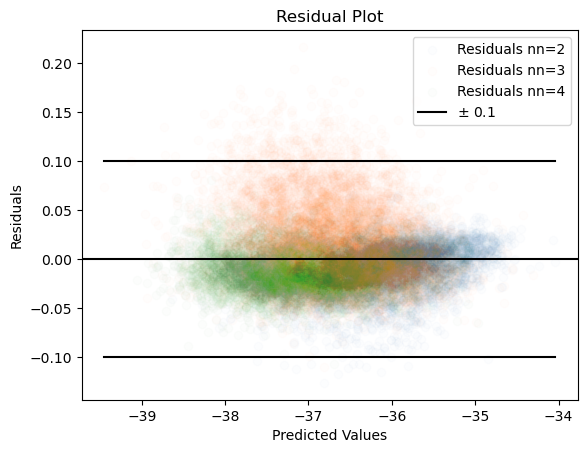

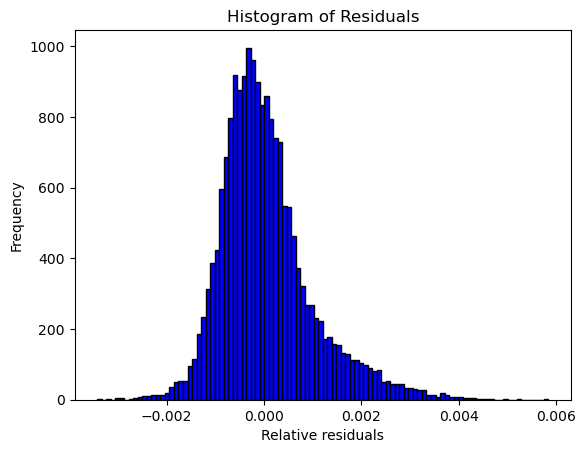

In [17]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=1e-2,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.1 * np.ones_like(x), color="k", label="$\pm$ 0.1")
plt.plot(x, -0.1 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.b = nn.Parameter(
            torch.tensor([0.15509141981601715, 0.2927597463130951])
        )  # Initialize the 'b' parameter
        self.c = nn.Parameter(
            torch.tensor([26.121471405029297, 37.5871696472168, 0.7215226292610168])
        )  # Initialize the 'c' parameter
        self.k = nn.Parameter(torch.ones(2))  # Initialize the 'k' parameter

    def forward(self, x):
        # return self.a * x + self.
        a = (self.b[0] - x["avgr"] ** 2) * x["vtot"] + self.k[0] * x["avgr"] ** 2 * x[
            "voff"
        ]
        b = (self.b[1] - x["avgr"] ** 2) * x["vtot"] + self.k[1] * x["avgr"] ** 2 * x[
            "voff"
        ]
        c = (self.b[1] - x["avgr"] ** 2) * x["vtot"] ** 2 + self.k[1] * x[
            "avgr"
        ] ** 2 * x["voff"] ** 2
        return (
            -self.c[0] * c / a + self.c[1] * torch.sqrt(a) + self.c[2] * torch.sqrt(b)
        )


# Convert data to torch tensors
X_torch = {}
X_torch["vtot"] = torch.tensor(Vtot, dtype=torch.float64)
X_torch["voff"] = torch.tensor(Voff, dtype=torch.float64)
X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=1000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

b = model.b
k = model.k
c = model.c

print("Model: ")
print(f"b = {b[0]} {b[1]} k = {k[0]} {k[1]} c = {c[0]} {c[1]} {c[2]}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.0091
Epoch [2/1000], Loss: 0.0020
Epoch [3/1000], Loss: 0.0019
Epoch [4/1000], Loss: 0.0019
Epoch [5/1000], Loss: 0.0019
Final Loss: 0.0019
Model: 
b = 0.1458069086074829 0.27576881647109985 k = 1.0049535036087036 1.009541630744934 c = 26.12360954284668 37.58675003051758 0.7208055853843689
R^2 Score: 0.9980701130683113


Text(0.5, 1.0, 'Histogram of Residuals')

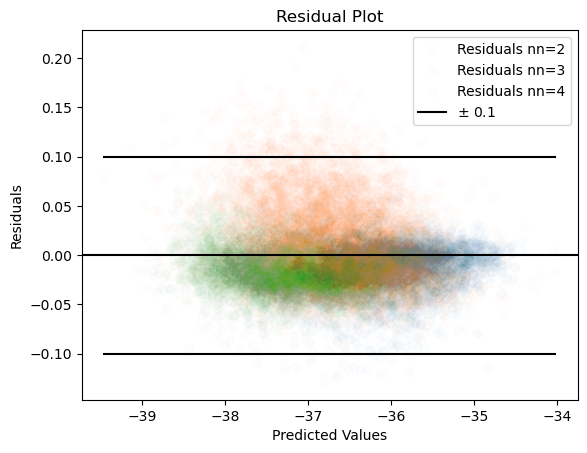

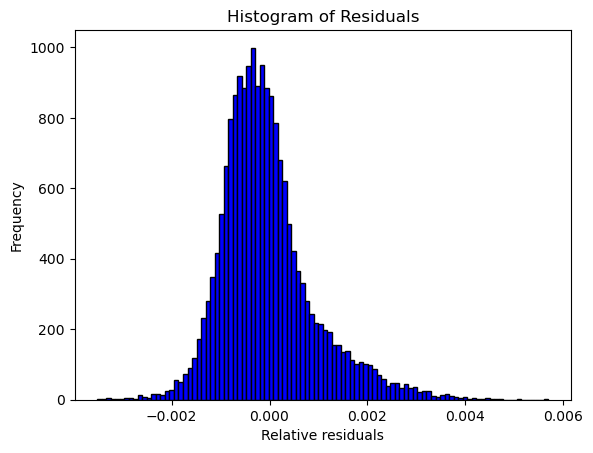

In [11]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=1e-2,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.1 * np.ones_like(x), color="k", label="$\pm$ 0.1")
plt.plot(x, -0.1 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

This pretty well capture the `nnn=2` and `nnn=4` cases. But `nnn=3` is still underestimated. It means that there's probably some non-linearity in the dependence.

#### Add more non-linear dependence on `nnn`

Try to set the numerator parameters free to capture the non-linear dependence on $V_{tot} - V_0$?

$$ -\mu = -c_1 \frac{(b_3 - \bar{a}^2) V^2_{tot} + k_3 \bar{a}^2 V_0^2}{(b_1 - \bar{a}^2) V_{tot} + k_1 \bar{a}^2 V_0} + c_2 \sqrt{(b_1 - \bar{a}^2) V_{tot} + k_1 \bar{a}^2 V_0} + c_3 \sqrt{(b_2 - \bar{a}^2) V_{tot} + k_2 \bar{a}^2 V_0} $$

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.b = nn.Parameter(
            torch.tensor([0.1458069086074829, 0.27576881647109985, 0.27576881647109985])
        )  # Initialize the 'b' parameter
        self.c = nn.Parameter(
            torch.tensor([26.12360954284668, 37.58675003051758, 0.7208055853843689])
        )  # Initialize the 'c' parameter
        self.k = nn.Parameter(
            torch.tensor([1.0049535036087036, 1.009541630744934, 1.009541630744934])
        )  # Initialize the 'k' parameter

    def forward(self, x):
        # return self.a * x + self.
        a = (self.b[0] - x["avgr"] ** 2) * x["vtot"] + self.k[0] * x["avgr"] ** 2 * x[
            "voff"
        ]
        b = (self.b[1] - x["avgr"] ** 2) * x["vtot"] + self.k[1] * x["avgr"] ** 2 * x[
            "voff"
        ]
        c = (self.b[2] - x["avgr"] ** 2) * x["vtot"] ** 2 + self.k[2] * x[
            "avgr"
        ] ** 2 * x["voff"] ** 2
        return (
            -self.c[0] * c / a + self.c[1] * torch.sqrt(a) + self.c[2] * torch.sqrt(b)
        )


# Convert data to torch tensors
X_torch = {}
X_torch["vtot"] = torch.tensor(Vtot, dtype=torch.float64)
X_torch["voff"] = torch.tensor(Voff, dtype=torch.float64)
X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=10000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

b = model.b
k = model.k
c = model.c

print("Model: ")
print(f"b = {b[0]} {b[1]} {b[2]} k = {k[0]} {k[1]} {k[2]} c = {c[0]} {c[1]} {c[2]}")
print(f"R^2 Score: {r2}")

Epoch [1/10000], Loss: 0.0023
Epoch [2/10000], Loss: 0.0022
Epoch [3/10000], Loss: 0.0021
Epoch [4/10000], Loss: 0.0020
Epoch [5/10000], Loss: 0.0020
Epoch [6/10000], Loss: 0.0021
Final Loss: 0.0021
Model: 
b = 0.14686861634254456 0.27576982975006104 0.2774817645549774 k = 1.0050081014633179 1.009549856185913 1.0098711252212524 c = 26.123613357543945 37.58675003051758 0.7208040952682495
R^2 Score: 0.9979493432100616


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class InteractionModel(nn.Module):
    def __init__(self):
        super(InteractionModel, self).__init__()
        self.b = nn.Parameter(
            torch.tensor([0.1458069086074829, 0.27576881647109985, 0.27576881647109985])
        )  # Initialize the 'b' parameter
        self.c = nn.Parameter(
            torch.tensor([26.12360954284668, 37.58675003051758, 0.7208055853843689])
        )  # Initialize the 'c' parameter
        self.k = nn.Parameter(
            torch.tensor([1.0049535036087036, 1.009541630744934, 0.5])
        )  # Initialize the 'k' parameter

    def forward(self, x):
        # return self.a * x + self.
        a = (self.b[0] - x["avgr"] ** 2) * x["vtot"] + self.k[0] * x["avgr"] ** 2 * x[
            "voff"
        ]
        b = (self.b[1] - x["avgr"] ** 2) * x["vtot"] + self.k[1] * x["avgr"] ** 2 * x[
            "voff"
        ]
        c = (self.b[2] - x["avgr"] ** 2) * x["vtot"] ** 2 + self.k[2] * x[
            "avgr"
        ] ** 2 * x["voff"] ** 2
        return (
            -self.c[0] * c / a + self.c[1] * torch.sqrt(a) + self.c[2] * torch.sqrt(b)
        )


# Convert data to torch tensors
X_torch = {}
X_torch["vtot"] = torch.tensor(Vtot, dtype=torch.float64)
X_torch["voff"] = torch.tensor(Voff, dtype=torch.float64)
X_torch["avgr"] = torch.tensor(avgr, dtype=torch.float64)
Y_torch = torch.tensor(Y, dtype=torch.float64)

# Initialize the model
model = InteractionModel()


def criterion(outputs, targets):
    # Define the MSE loss
    mse_loss = nn.MSELoss()

    # Inside your training loop
    loss = mse_loss(outputs, targets) / (
        torch.var(targets) if torch.var(targets) != 0 else 1.0
    )
    return loss


def regression(X, Y, model: nn.Module, maxiter=10000, tol=1e-9):
    # optimizer = optim.SGD(model.parameters(), lr=0.01)
    # Using L-BFGS Optimizer
    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.005,
        max_iter=maxiter,
        tolerance_grad=tol * 1e2,
        tolerance_change=tol,
    )

    # Training Loop
    loss_old = torch.inf
    loss_new = torch.inf

    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        return loss

    # Training Loop
    for epoch in range(maxiter):  # Number of epochs
        if loss_old - loss_new < tol:
            break
        loss_old = loss_new

        optimizer.step(closure)
        loss = closure().item()
        loss_new = loss
        if epoch % 1 == 0:
            print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")

    print(f"Final Loss: {loss_new:.4f}")
    return model


def r_squared(X, Y, model: nn.Module):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


model = regression(X_torch, Y_torch, model)
r2 = r_squared(X_torch, Y_torch, model)

b = model.b
k = model.k
c = model.c

print("Model: ")
print(f"b = {b[0]} {b[1]} {b[2]} k = {k[0]} {k[1]} {k[2]} c = {c[0]} {c[1]} {c[2]}")
print(f"R^2 Score: {r2}")

Epoch [1/10000], Loss: 0.0019
Epoch [2/10000], Loss: 0.0019
Epoch [3/10000], Loss: 0.0019
Final Loss: 0.0019
Model: 
b = 0.13418994843959808 0.2622049152851105 0.251861572265625 k = 1.0137358903884888 0.9777048826217651 1.0279028415679932 c = 26.153736114501953 37.57919692993164 0.7093501687049866
R^2 Score: 0.9981328934086251


Text(0.5, 1.0, 'Histogram of Residuals')

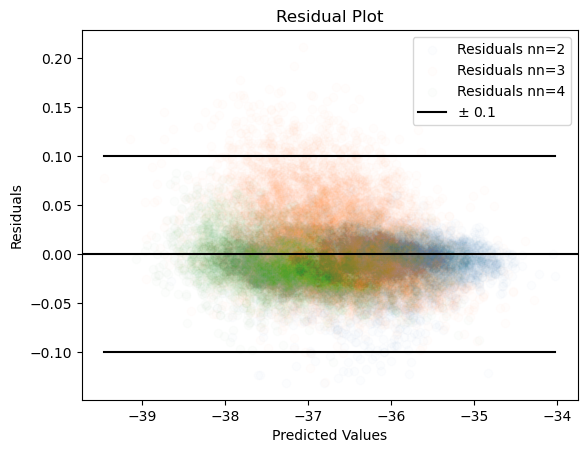

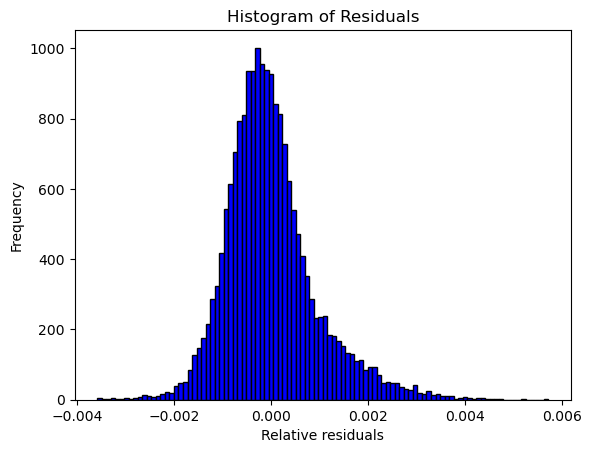

In [23]:
import matplotlib.pyplot as plt


# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()

# Plotting residuals
plt.figure()
# Plotting the original data
for i in [2, 3, 4]:
    plt.scatter(
        predictions_np[:, nno == i].flatten(),
        residuals_np[:, nno == i].flatten(),
        # color="blue",
        alpha=1e-2,
        label=f"Residuals nn={i}",
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(np.min(predictions_np), np.max(predictions_np), 100)
plt.plot(x, 0.1 * np.ones_like(x), color="k", label="$\pm$ 0.1")
plt.plot(x, -0.1 * np.ones_like(x), color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

So far the best model.

The model is not much improved.

This just means that the model has run out of its capacity. The residual cannot be captured is probably from the error of model assumption.